11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 512s 533ms/step - accuracy: 0.5331 - loss: 1.5630 - val_accuracy: 0.9752 - val_loss: 0.0777 - learning_rate: 5.0000e-04
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 487s 519ms/step - accuracy: 0.9080 - loss: 0.2953 - val_accuracy: 0.9779 - val_loss: 0.0714 - learning_rate: 5.0000e-04
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 490s 522ms/step - accuracy: 0.9440 - loss: 0.1807 - val_accuracy: 0.9889 - val_loss: 0.0343 - learning_rate: 5.0000e-04
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 489s 521ms/step - accuracy: 0.9597 - loss: 0.1362 - val_accuracy: 0.9872 - val_loss: 0.0406 - learning_rate: 5.0000e-04
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 493s 511ms/step - accuracy: 0.9662 - loss: 0.1122 - val_accuracy: 0.9908 - val_loss: 0.0267 - learning_rate: 5.0000e-04
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 483s 514ms/step - accuracy: 0.9709 - loss: 0.0974 - val_accuracy: 0.9878 - val_loss: 0.0393 - learning_rate: 5.0000e-04
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 490s 522ms/

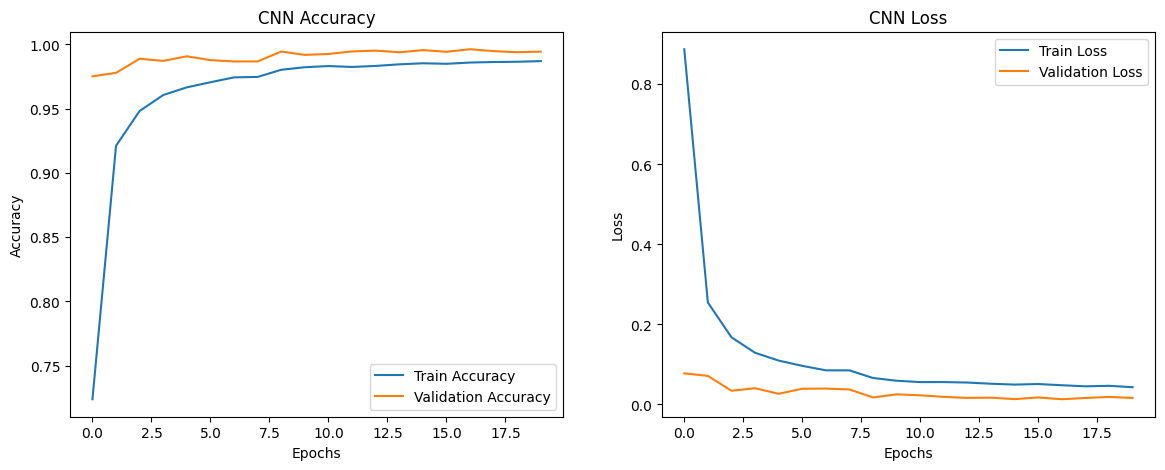

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step


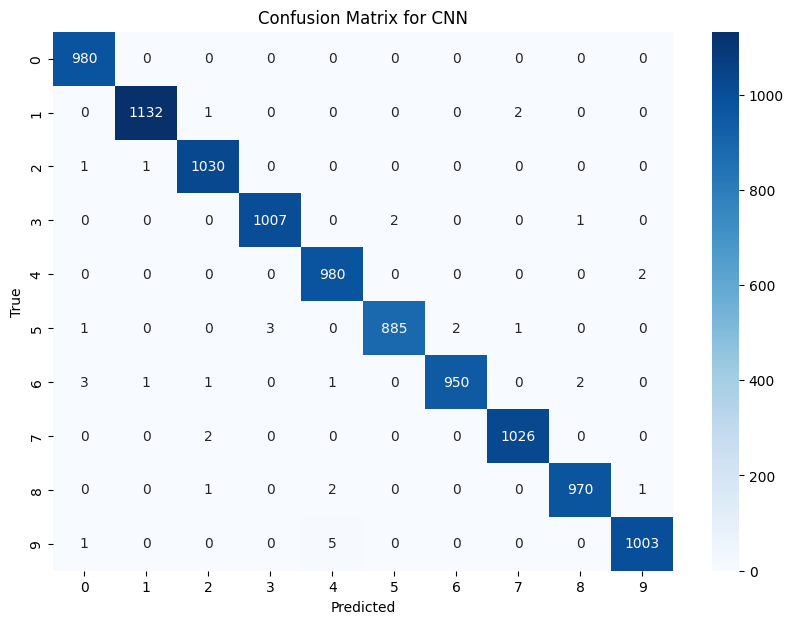

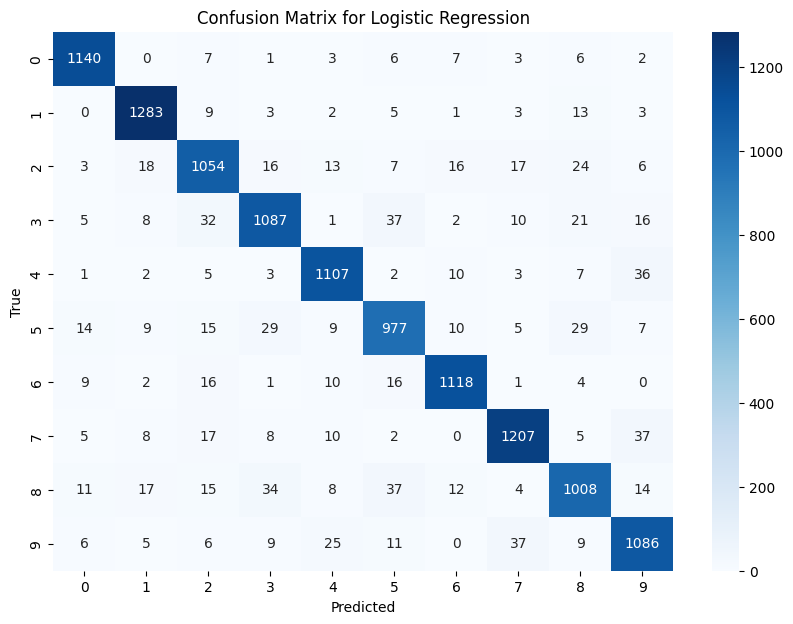

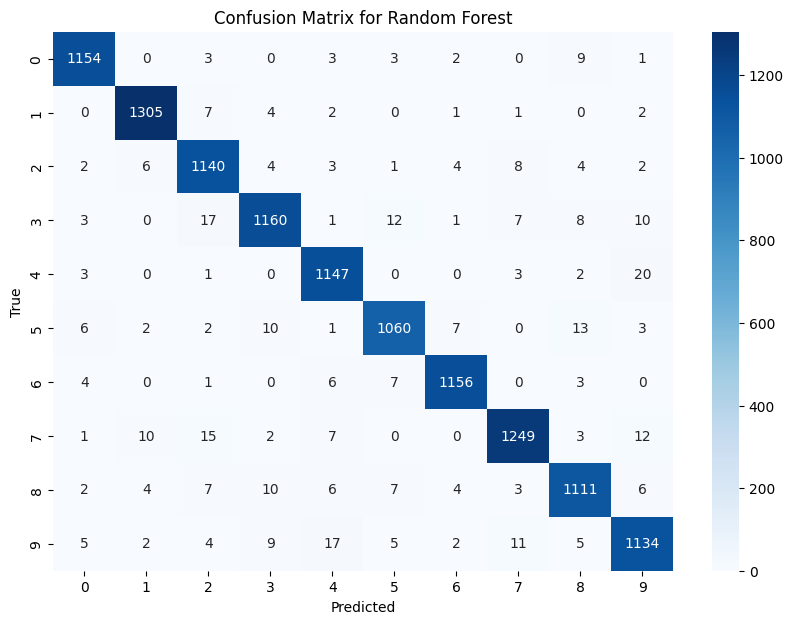

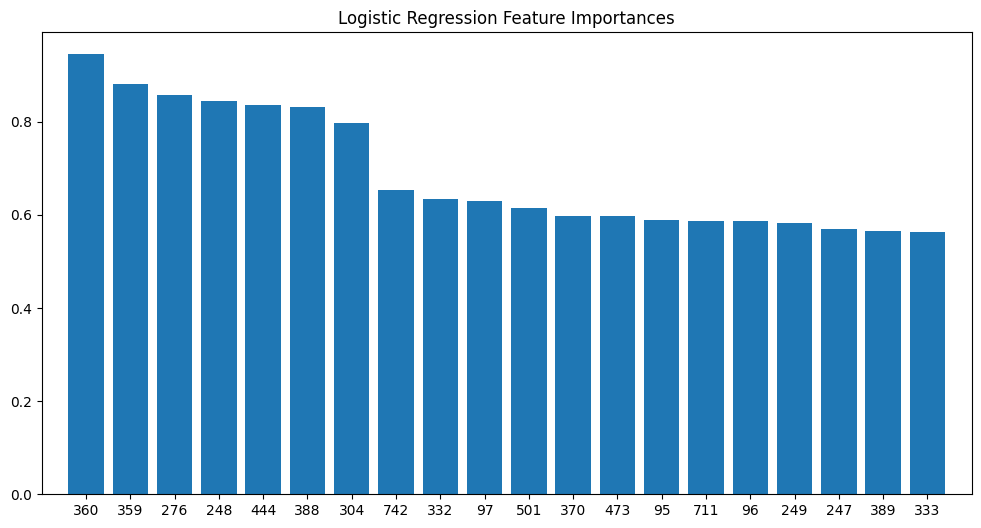

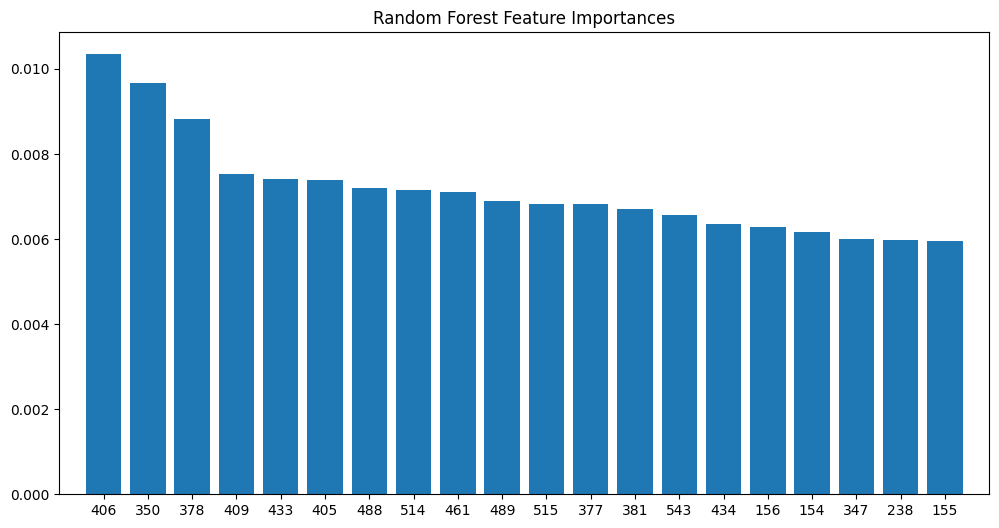

LOGISTIC REGRESSION SAMPLE PREDICTION


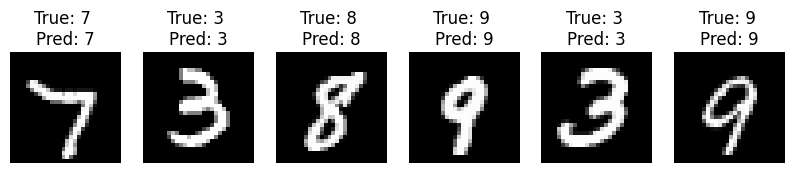

RANDOM FOREST SAMPLE PREDICTION


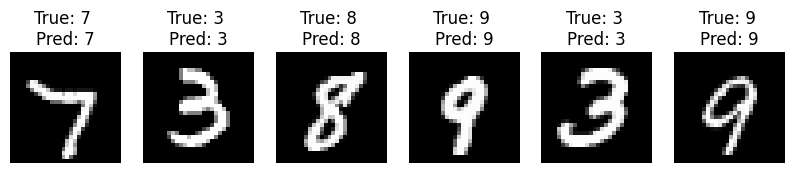

CNN SAMPLE PREDICTION


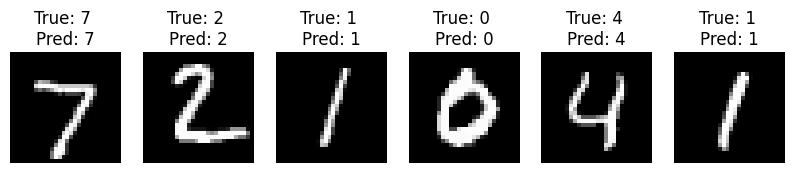

In [ ]:
# STEP 1: ACQUIRE DATA
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# STEP 2: PREPROCESS DATA
# Preprocess data for Logistic Regression and RandomForest (flatten images and normalize)
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

# Preprocess data for CNN (reshape for CNN input and normalize)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2
)
datagen.fit(X_train_cnn)

# STEP 3: BUILD AND TRAIN CNN MODEL
# Build an enhanced CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the CNN model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy', metrics=['accuracy'])

# Set up early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6)

# Train the CNN model with data augmentation
history = model.fit(datagen.flow(X_train_cnn, y_train_cnn, batch_size=64),
                    epochs=20, validation_data=(X_test_cnn, y_test_cnn),
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

# Additional preprocessing for Random Forest and Logistic Regression Models
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_train_flat, y_train, test_size=0.2, random_state=42)

# Initialize and Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_rf, y_train_rf)
y_pred_log_reg = log_reg.predict(X_val_rf)

# Initialize and Train Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_val_rf)

# STEP 4: EVALUATE MODELS
# Logistic Regression Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_val_rf, y_pred_log_reg))
print(classification_report(y_val_rf, y_pred_log_reg))

# Random Forest Evaluation
print("Random Forest Accuracy:", accuracy_score(y_val_rf, y_pred_rf))
print(classification_report(y_val_rf, y_pred_rf))

# CNN Model Evaluation on the test set
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"Test Accuracy (CNN): {test_accuracy * 100:.2f}%")

# Plot CNN Loss and Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix for CNN
y_true = np.argmax(y_test_cnn, axis=-1)
y_pred_cnn = np.argmax(model.predict(X_test_cnn), axis=-1)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CNN')
plt.show()

# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_val_rf, y_pred_log_reg)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_val_rf, y_pred_rf)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest')
plt.show()

# STEP 5: VISUALIZATIONS AND RESULT
# Logistic Regression Feature Importance
coefficients = np.abs(log_reg.coef_)
mean_coefficients = np.mean(coefficients, axis=0)
indices = np.argsort(mean_coefficients)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Logistic Regression Feature Importances")
plt.bar(range(20), mean_coefficients[indices][:20], align='center')
plt.xticks(range(20), indices[:20])
plt.xlim([-1, 20])
plt.show()

# Random Forest Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(20), importances[indices][:20], align='center')
plt.xticks(range(20), indices[:20])
plt.xlim([-1, 20])
plt.show()

# Sample Predictions for Visualization
def plot_sample_predictions(X, y_true, predictions, num_samples=6):
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.title(f'True: {y_true[i]} \nPred: {predictions[i]}')
        plt.axis('off')
    plt.show()

# Plot Predictions for Logistic Regression
print('LOGISTIC REGRESSION SAMPLE PREDICTION')
plot_sample_predictions(X_val_rf.reshape(-1, 28, 28), y_val_rf, y_pred_log_reg)

# Plot Predictions for Random Forest
print('RANDOM FOREST SAMPLE PREDICTION')
plot_sample_predictions(X_val_rf.reshape(-1, 28, 28), y_val_rf, y_pred_rf)

# CNN Sample Predictions
print('CNN SAMPLE PREDICTION')
plot_sample_predictions(X_test, y_true, y_pred_cnn, num_samples=6)
